In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


In [ ]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

In [ ]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

# Load HGA

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        'TIMIT'
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'

HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 1361/1361 [00:53<00:00, 25.39it/s] 


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


# Speaker suppression

roi  condition
HG   Listen        28
     Speak         28
STG  Listen       131
     Speak        118
Name: channel, dtype: int64


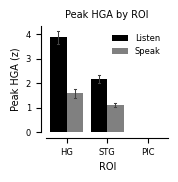

In [4]:
# 筛选目标脑区和条件 - 调整顺序
from matplotlib.ticker import MultipleLocator

rois_compare = ['HG', 'STG', 'PIC']  # HG -> STG -> PIC
phases_compare = ['stimulus', 'response']  # stimulus=听, response=说

# 筛选数据
df_compare = HGAs[
    (HGAs['roi'].isin(rois_compare)) &
    (HGAs['phase'].isin(phases_compare)) &
    (HGAs['description'] == 'Repeat') &
    (HGAs['modality'] == 'sound') &
    (HGAs['time'] > 0) & (HGAs['time'] < 1) 
].copy()

# 计算每个电极的 peak 和 mean HGA
electrode_stats = df_compare.groupby(['channel', 'roi', 'phase']).agg(
    peak_hga=('value', 'max'),
    mean_hga=('value', 'mean')
).reset_index()

# 重命名 phase 为更直观的名称
electrode_stats['condition'] = electrode_stats['phase'].map({
    'stimulus': 'Listen',
    'response': 'Speak'
})

fig, ax = plt.subplots(1, 1, figsize=(4*cm, 3.5*cm))

sns.barplot(data=electrode_stats, 
            x='roi',
            y='peak_hga', 
            hue='condition',
            palette={'Listen': 'black', 'Speak': 'gray'},
            order=rois_compare, 
            ax=ax, 
            errorbar='se', 
            capsize=0.1,
            errwidth=0.75)


ax.set_xlabel('ROI', fontsize=fontsize)
ax.set_ylabel('Peak HGA (z)', fontsize=fontsize)
ax.set_title('Peak HGA by ROI', fontsize=fontsize)
ax.legend(title='', fontsize=fontsize-1, frameon=False)
ax.yaxis.set_major_locator(MultipleLocator(1))

for ax in fig.axes:
    ax.tick_params(labelsize=fontsize-1)
    sns.despine(ax=ax, offset=4)


print(electrode_stats.groupby(['roi', 'condition'])['channel'].nunique())
plt.savefig('../img/fig2/fig2_peak_hga_by_roi.svg', dpi=300)

In [5]:
# Build scatter_df: align each electrode's Perception vs Production
metric = 'peak_hga'  # or 'peak_hga'

scatter_df = (
    electrode_stats
    .pivot_table(index=['channel', 'roi'], columns='condition', values=metric, aggfunc='first')
    .dropna(subset=['Listen', 'Speak'])
    .reset_index()
)

# add coords/metadata back (one row per channel)
coords = (HGAs.groupby('channel')[['x','y','z','hemi','subject','label']].first().reset_index())
scatter_df = scatter_df.merge(coords, on='channel', how='left')

scatter_df.head()

,channel,roi,Listen,Speak,x,y,z,hemi,subject,label
0,D0005_LTG14-15,STG,3.506131,1.376253,-68.886726,-28.295294,0.243498,L,D0005,ctx_lh_G_temp_sup-Lateral
1,D0005_LTG15-16,STG,3.157964,1.245044,-69.639740,-38.151283,4.609248,L,D0005,ctx_lh_G_temp_sup-Lateral
2,D0005_LTG4-5,STG,2.213470,0.749295,-63.895071,-1.988314,1.863490,L,D0005,ctx_lh_G_temp_sup-Lateral
3,D0022_LMIF5-6,HG,2.216819,1.285263,-49.716957,-12.270617,-12.142812,L,D0022,ctx_lh_S_temporal_transverse
4,D0022_LPIF6-7,HG,2.596237,2.990733,-53.301873,-21.967834,-6.588691,L,D0022,ctx_lh_S_temporal_transverse


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


2026-02-20 20:28:51.008 (  65.823s) [    7F0F21FC7440]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-20 20:28:51.057 (  65.872s) [    7F0F21FC7440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x3c02cab0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-20 20:28:51.196 (  66.010s) [    7F0F21FC7440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x3c0977c0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D 

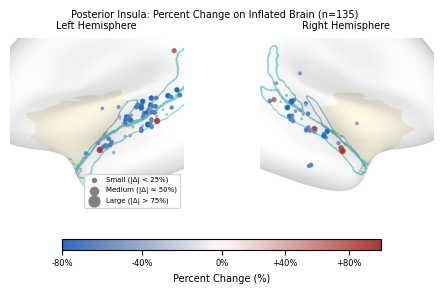

In [6]:
# ============================================================
# 方案二: 在 Inflated Brain 上画 Percent Change (仅 PIC)
# 使用 vlag colormap 展示 Posterior Insula 的抑制梯度
# ============================================================

from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors
import pyvista as pv

# 使用上面计算好的 scatter_df，只筛选 Posterior Insula
rois_brain = ['PIC', 'HG', 'STG']  # 只显示 Posterior Insula
brain_df = scatter_df[scatter_df['roi'].isin(rois_brain)].copy()

# 计算百分比变化（相对于 Perception）
brain_df['Percent_Change'] = (brain_df['Speak'] - brain_df['Listen']) / brain_df['Listen'] * 100

# 读取labels用于过滤电极
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# 构建每个ROI对应的label顶点集合
def get_roi_vertices(labels, roi_name, hemi):
    vertices = set()
    for lab in labels:
        name = lab.name
        if lab.hemi != hemi:
            continue
        if roi_name == 'PIC' and 'ins' in name.lower():
            vertices.update(lab.vertices)
    return vertices

# 创建Brain对象 - 使用 inflated 表面
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.95, 0.95, 0.95), alpha=0.3, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.95, 0.95, 0.95), alpha=0.3, size=(800, 800)
)

# 加载表面数据
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
lh_infl_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.inflated")
lh_tree = cKDTree(lh_pial_coords)

rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
rh_infl_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.inflated")
rh_tree = cKDTree(rh_pial_coords)

# 使用 seaborn 的 vlag colormap
cmap = sns.color_palette("vlag", as_cmap=True)  # vlag: 蓝-白-红

# 根据实际数据范围设置 colormap 和大小映射
pc_values = brain_df['Percent_Change'].values
vmin, vmax = -80, 100  # 百分比范围
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# 点大小映射参数 - 基于百分比变化的绝对值
size_min, size_max = 4, 30

def percent_change_to_size(pc, size_min, size_max):
    """根据百分比变化的绝对值映射点大小"""
    abs_pc = np.abs(pc)
    # 将绝对百分比映射到大小范围
    normalized = np.clip(abs_pc / 100, 0, 1)  # 归一化到 0-1
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_percent_change_size(brain, coords, pc_vals, tree, pial_coords, infl_coords, cmap, norm, size_min, size_max):
    _, indices = tree.query(coords)
    coords_on_infl = infl_coords[indices]
    
    for i in range(len(coords_on_infl)):
        pt = coords_on_infl[i:i+1]
        pc = pc_vals[i]
        
        # 颜色基于百分比变化（使用 vlag colormap）
        color = cmap(norm(pc))[:3]
        
        # 大小基于百分比变化的绝对值
        size = percent_change_to_size(pc, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            opacity=1,
        )

# 准备数据
cord = brain_df[['x', 'y', 'z']].values
pc_values = brain_df['Percent_Change'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_pc = pc_values[mask_lh]
    add_electrodes_with_percent_change_size(lh_brain, lh_cord, lh_pc, lh_tree, lh_pial_coords, lh_infl_coords, 
                                           cmap, norm, size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_pc = pc_values[mask_rh]
    add_electrodes_with_percent_change_size(rh_brain, rh_cord, rh_pc, rh_tree, rh_pial_coords, rh_infl_coords, 
                                           cmap, norm, size_min, size_max)

# 添加 ROI 边界
# Posterior Insula 边界

insula_patterns = [
    'G_insular_short',
    'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant',
    'S_circular_insula_inf',
    'S_circular_insula_sup',
]

for lab in labels:
    name = lab.name
    if any(p in name for p in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# STG 边界
for lab in labels:
    name = lab.name
    if 'G_temp_sup' in name:
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=True, color=stg_color, alpha=0.8)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=True, color=stg_color, alpha=0.8)

# 计算听觉相关脑区的中心点，用于调整视角
def get_roi_center(labels, roi_patterns, hemi):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in roi_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        if hemi == 'lh':
            coords = lh_infl_coords[vertices]
        else:
            coords = rh_infl_coords[vertices]
        return coords.mean(axis=0)
    return None

# 听觉相关脑区模式
auditory_patterns = ['G_temp_sup', 'G_temp_sup-G_T_transv'] + insula_patterns
lh_auditory_center = get_roi_center(labels, auditory_patterns, 'lh')
rh_auditory_center = get_roi_center(labels, auditory_patterns, 'rh')

# 设置视角 - 聚焦在听觉区域
for brain, center in [(lh_brain, lh_auditory_center), (rh_brain, rh_auditory_center)]:
    if center is not None:
        brain.show_view(azimuth=180 if brain == lh_brain else 0, 
                       elevation=90, 
                       distance=230,  # 缩短距离，更聚焦
                       focalpoint=center)
    else:
        brain.show_view(view="lateral", distance=150)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(15*cm, 7*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Hemisphere", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Hemisphere", fontsize=fontsize)

# 添加 colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, aspect=30)
cbar.set_label('Percent Change (%)', fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize-1)
cbar.set_ticks([-80, -40, 0, 40, 80])
cbar.ax.set_xticklabels(['-80%', '-40%', '0%', '+40%', '+80%'])

# 添加大小图例
from matplotlib.patches import Patch
size_legend_elements = [
    plt.scatter([], [], s=size_min*2, c='gray', label=f'Small (|Δ| < 25%)'),
    plt.scatter([], [], s=(size_min + (size_max-size_min)*0.5)*2, c='gray', label=f'Medium (|Δ| ≈ 50%)'),
    plt.scatter([], [], s=size_max*2, c='gray', label=f'Large (|Δ| > 75%)')
]
axes[0].legend(handles=size_legend_elements, loc='lower right', fontsize=fontsize-2, framealpha=0.8)

plt.suptitle("Posterior Insula: Percent Change on Inflated Brain (n={})".format(len(brain_df)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.25)
plt.savefig('../img/fig2/fig2_SIS.svg', dpi=300, bbox_inches='tight')